In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

In [74]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.1, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def _compute_loss(self, y, y_pred):
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear_model)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # record loss
            loss = self._compute_loss(y, y_pred)
            self.loss_history.append(loss)

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def plot_convergence(self):
        plt.figure()
        plt.plot(self.loss_history)
        plt.title("Logistic Regression Loss Convergence")
        plt.xlabel("Iteration")
        plt.ylabel("Binary Cross-Entropy Loss")
        plt.show()

    def roc_auc_analysis(self, X, y):
        proba = self.predict_proba(X)
        auc = roc_auc_score(y, proba)
        fpr, tpr, _ = roc_curve(y, proba)
        
        plt.figure()
        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
        plt.title("ROC Curve")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.legend()
        plt.show()
        
        print(f"ROC AUC Score: {auc:.3f}")
        return auc

    def plot_confusion_matrix(self, X, y, threshold=0.5):
        preds = self.predict(X, threshold)
        cm = confusion_matrix(y, preds)
        disp = ConfusionMatrixDisplay(cm)
        disp.plot(cmap="Blues")
        plt.title("Confusion Matrix")
        plt.show()
        print("Confusion Matrix:")
        print(cm)
    def unit_tests(self):
        # Test 1: Loss decreases
        X = np.random.randn(100, 2)
        y = (np.dot(X, np.array([1, -2])) + 0.5 > 0).astype(int)
        self.fit(X, y)
        assert self.loss_history[0] > self.loss_history[-1], "Loss did not decrease"

        # Test 2: Prediction shape
        preds = self.predict(X)
        assert preds.shape == y.shape, "Prediction shape mismatch"

        # Test 3: Simple separable data
        X_simple = np.array([[0], [1], [2], [3]])
        y_simple = np.array([0, 0, 1, 1])
        model_simple = LogisticRegressionScratch(lr=0.5, n_iters=5000)
        model_simple.fit(X_simple, y_simple)
        preds_simple = model_simple.predict(X_simple)
        assert np.array_equal(preds_simple, y_simple), f"Simple data misclassified: {preds_simple} vs {y_simple}"

        print("All LogisticRegressionScratch unit tests passed!")
        return True


In [75]:
# Gather data and merge the wines together
df1 = pd.read_csv("winequality-white.csv", sep=";")
df2 = pd.read_csv("winequality-red.csv",   sep=";")
df1["color"] = "white"
df2["color"] = "red"
df = pd.concat([df1, df2], axis=0, ignore_index=True)
# Convert categorical targets into binary targets (0=white, 1=red)
df['color'] = df['color'].map({'white': 0, 'red': 1})
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,color
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0


In [76]:
# We will aim to predict color using all of the features provided
y = df['color']
X = df.drop(['color'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [77]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_np = X_train_scaled.values if hasattr(X_train_scaled, "values") else X_train_scaled
y_train_np = y_train.values      if hasattr(y_train,     "values") else y_train
y_train_np = y_train_np.ravel()

In [78]:
# Fit and run tests
model = LogisticRegressionScratch()
model.unit_tests()
model = LogisticRegressionScratch()
model.fit(X_train, y_train)

All LogisticRegressionScratch unit tests passed!


## Iteration Results
- **Steep Initial Drop**  
  In the first ~10–20 iterations, the binary cross‐entropy plunges from ≈12 down to ≈6, indicating the model quickly finds a reasonable decision boundary.  
- **Persistent Oscillations**  
  After the initial descent, the loss curve becomes **highly jagged**, with frequent spikes and troughs between ≈1 and ≈5. This suggests:  
  - A relatively large learning rate causing overshooting.  
  - No batch‐smoothing—every update uses the entire dataset, so numerical precision or gradient variance may amplify oscillations.  
- **Slow Settling**  
  Around iteration ~200 onward, the loss oscillates around a more stable band (≈1.5–3.5) but never fully “flattens.” Further iterations yield diminishing overall improvement, yet still large short‐term swings.

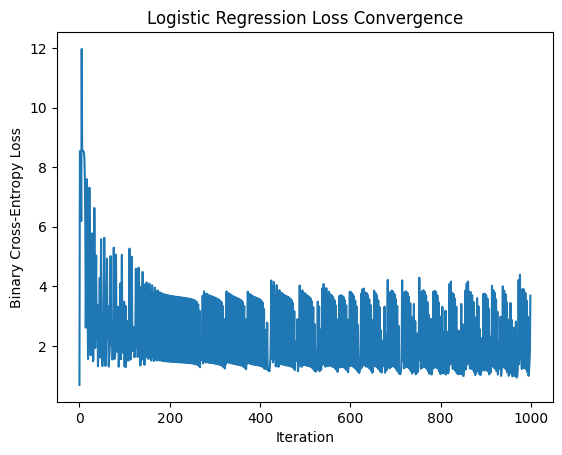

In [79]:
model.plot_convergence()

## Model Evaluation
- The confusion matrix shows that the model has approximately 90% accuracy on classification of wine color.
- The ROC AUC analysis yielded a score of approximately 0.96, which is very favorable and suggests that the model is robust model (i.e. that the accuracy in the confusion matrix stands up to reshuffling of training and test sets)

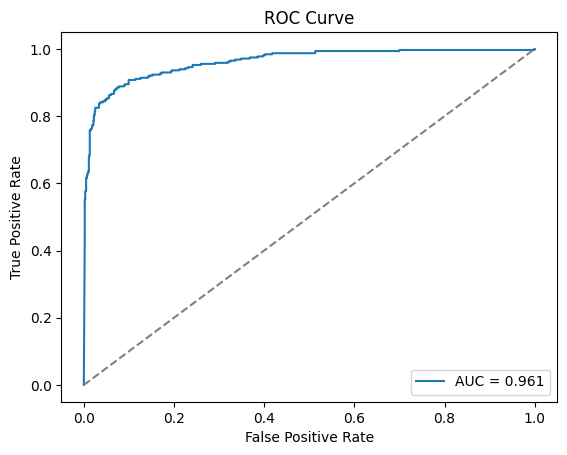

ROC AUC Score: 0.961


0.9614830557744733

In [80]:
model.roc_auc_analysis(X_test, y_test)

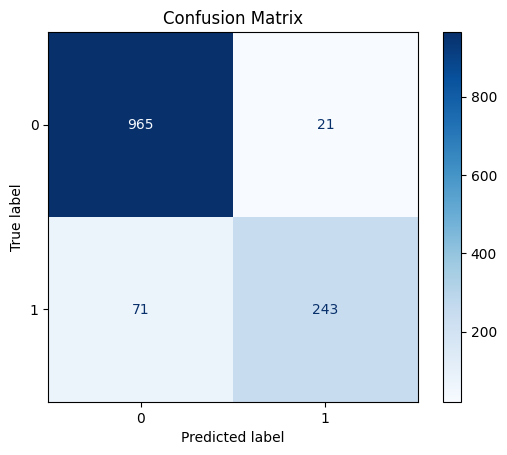

Confusion Matrix:
[[965  21]
 [ 71 243]]


In [81]:
model.plot_confusion_matrix(X_test, y_test)